Problem Statement: The goal of this project is to build a Machine Learning classification model to predict whether a customer will churn (leave the network) based on their demographics, subscribed services, and account information. This will allow the business to proactively target at-risk customers with retention strategies.

## Data Dictionary
To understand the data, we can group our 20 columns into 4 logical categories:

**1. Customer Demographics:**
* `gender`: Whether the customer is a male or a female.
* `SeniorCitizen`: Whether the customer is a senior citizen or not (1 = Yes, 0 = No).
* `Partner`: Whether the customer has a partner or not (Yes, No).
* `Dependents`: Whether the customer has dependents/children or not (Yes, No).

**2. Account & Billing Information:**
* `tenure`: Number of months the customer has stayed with the company. *(Crucial feature!)*
* `Contract`: The contract term of the customer (Month-to-month, One year, Two year).
* `PaperlessBilling`: Whether the customer has paperless billing or not (Yes, No).
* `PaymentMethod`: The customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card).
* `MonthlyCharges`: The amount charged to the customer monthly.
* `TotalCharges`: The total amount charged to the customer over their entire tenure.

**3. Subscribed Services:**
* `PhoneService`: Whether the customer has a phone service or not.
* `MultipleLines`: Whether the customer has multiple phone lines or not.
* `InternetService`: Customer’s internet service provider (DSL, Fiber optic, No).
* `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`: Various add-on services provided by the company (Yes, No, or No internet service).

**4. Target Variable:**
* `Churn`: Whether the customer churned/left within the last month or not (Yes or No).

In [13]:
import pandas as pd
import numpy as np

In [14]:
df=pd.read_csv('/content/customer_churn.csv')

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
print(f"Dataset Shape: {df.shape}\n")
df.info()

Dataset Shape: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

The information of this data can be divided based on the columns provided to us, like the initial columns tell us about the demographic of customers while the next few columns tell us about the Account & Billing Information.

As it is visible from the sample, the customerID column is of no use for our EDA or the model we train. Its just there for indexing and we can definitely drop that.


In [17]:
df.drop('customerID', axis=1, inplace=True)

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Moving to the next feature, we have the gender column. Lets look at what all values it takes and handle any possible typos or things or same sort.

In [19]:
print(f"Unique values: {df['gender'].unique()}")
print(f"Null values: {df['gender'].isnull().sum()}")
print("\nValue Counts:")
print(df['gender'].value_counts())

Unique values: ['Female' 'Male']
Null values: 0

Value Counts:
gender
Male      3555
Female    3488
Name: count, dtype: int64


As visible, the gender column has no missing value.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

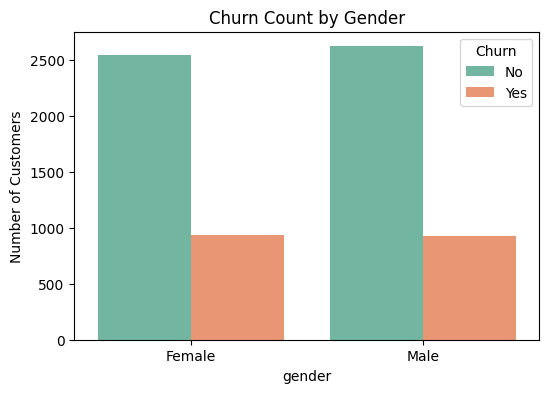

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='Churn', palette='Set2')
plt.title('Churn Count by Gender')
plt.ylabel('Number of Customers')
plt.show()

The orange bars (Churn = Yes) are identical for both males and females. The green bars are also identical.

What does this tell us? It tells us that gender has absolutely no correlation with whether a person churns or not. People are churning for other reasons, not because of their gender. We will leave the column as is for now, but we will keep this in the back of our mind that it probably won't be an important feature for our ML model.

Claim 1: gender isn't an important feature here.

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Moving onto the Senior Citizen column

In [23]:
print(f"Unique values: {df['SeniorCitizen'].unique()}")
print(f"Null values: {df['SeniorCitizen'].isnull().sum()}")
print("\nValue Counts:")
print(df['SeniorCitizen'].value_counts())

Unique values: [0 1]
Null values: 0

Value Counts:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


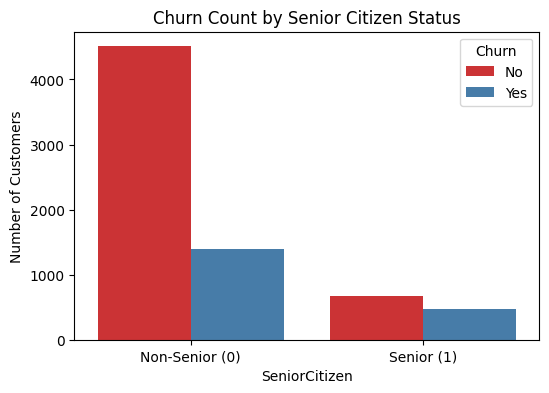

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set1')
plt.title('Churn Count by Senior Citizen Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Non-Senior (0)', 'Senior (1)'])
plt.show()

Unlike gender, SeniorCitizen is going to be a very important feature for our machine learning model because it clearly influences customer behavior.
The red and blue bars are much closer together. Even though there are fewer seniors overall, their proportion of churn is much higher.

Seniors might be finding the technology too hard to use.

Or the plans too expensive, causing them to leave.

Claim 2: being a senior citizen influences the churn prediction.

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Lets look at the Partner and Dependents columns together because both of these basically ask:

 Does this customer live alone, or do they have a family?

  Usually, families want stable, long-term internet/phone plans, whereas single people might move around and switch providers more often.

  Claim 3: the customers who have someone living with them often look for long term committment.
  
  Let's see if the data backs this or not.

Partner Unique Values: ['Yes' 'No']
Dependents Unique Values: ['No' 'Yes']


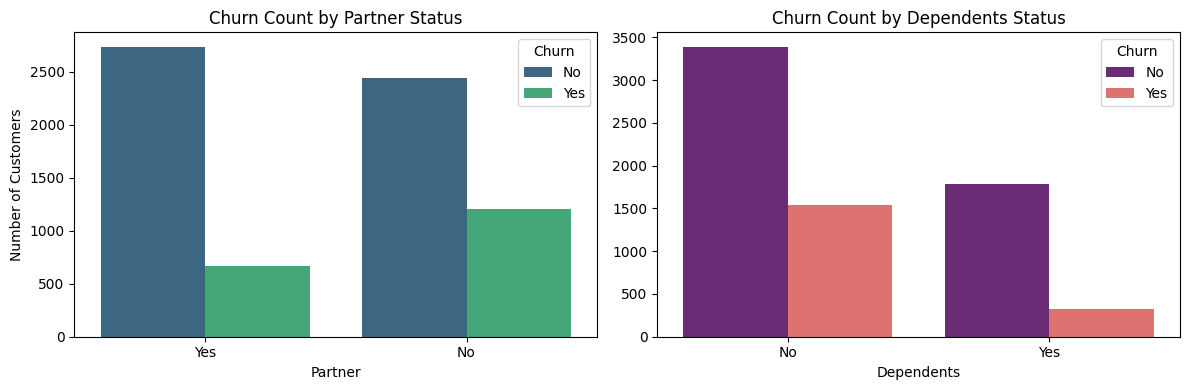

In [26]:
print("Partner Unique Values:", df['Partner'].unique())
print("Dependents Unique Values:", df['Dependents'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Partner', hue='Churn', palette='viridis', ax=axes[0])
axes[0].set_title('Churn Count by Partner Status')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=df, x='Dependents', hue='Churn', palette='magma', ax=axes[1])
axes[1].set_title('Churn Count by Dependents Status')
axes[1].set_ylabel('') # Hide y-label for the second plot to make it clean

plt.tight_layout()
plt.show()

Look at the people with No Partner and No Dependents, their churn bars (the green and red ones) are drastically higher in proportion. Single customers are much more likely to leave the telecom company, whereas customers with families tend to stick around.

In [27]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Now lets look at the tenure (in number of months)

--- TENURE COLUMN ANALYSIS ---
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


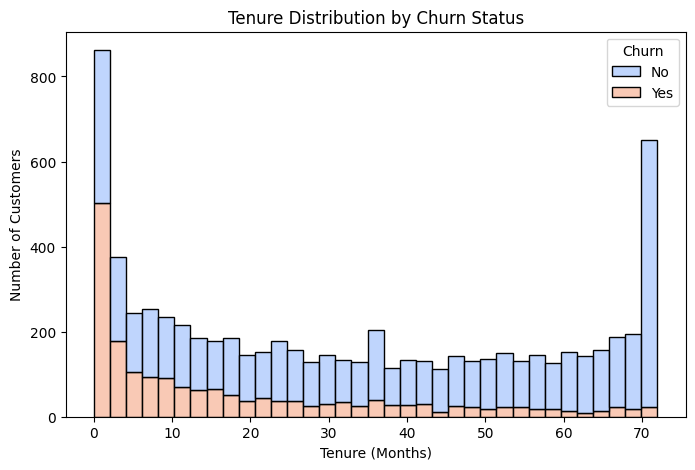

In [28]:
print("--- TENURE COLUMN ANALYSIS ---")
print(df['tenure'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=35, palette='coolwarm')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

 Look at that massive spike on the far left. Customers are extremely likely to churn within their first 1 to 5 months. But as you look to the right side of the graph (around 60 to 72 months), the orange "Churn" bar almost completely disappears. Once a customer stays for a few years, they become incredibly loyal.

I am also concerned with the minimum tenure being 0 months here. Were they even charged for the month or not?

In [29]:
df[df['tenure'] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Interesting find.

The TotalCharges do not exist for them.

The churn is No for all of them.

The contract is two years long in most cases.

This tells us these are brand new customers who just locked into long-term deals. Hence they haven't been charged yet.

These types of customers will be useless for our churn prediction, so we will dorp these rows.

In [30]:
df = df[df['tenure'] != 0]

print(f"New Dataset Shape: {df.shape}")
print(f"Number of customers with tenure=0 remaining: {len(df[df['tenure'] == 0])}")

New Dataset Shape: (7032, 20)
Number of customers with tenure=0 remaining: 0


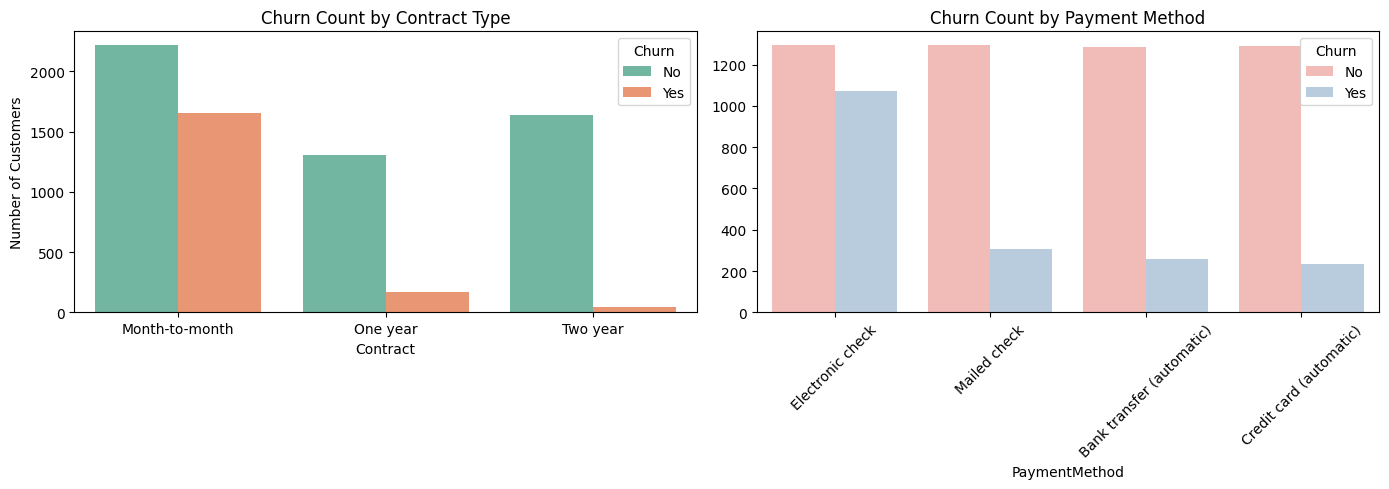

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn Count by Contract Type')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Pastel1', ax=axes[1])
axes[1].set_title('Churn Count by Payment Method')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The Contract Trap: Look at the Month-to-month bar. Almost half of those customers churn! Meanwhile, customers on a One-year or Two-year contract almost never leave. This perfectly aligns with our tenure graph (people churn in the first few months before locking in).

The Friction of Payment: Look at Electronic check. The churn rate there is astronomically high compared to the other three. Why? Because the other methods (Credit Card, Bank Transfer) are mostly automatic. "Set it and forget it." Electronic checks require manual effort every month, reminding the customer how much they are paying, which prompts them to cancel.

--- CORE SERVICES ANALYSIS ---


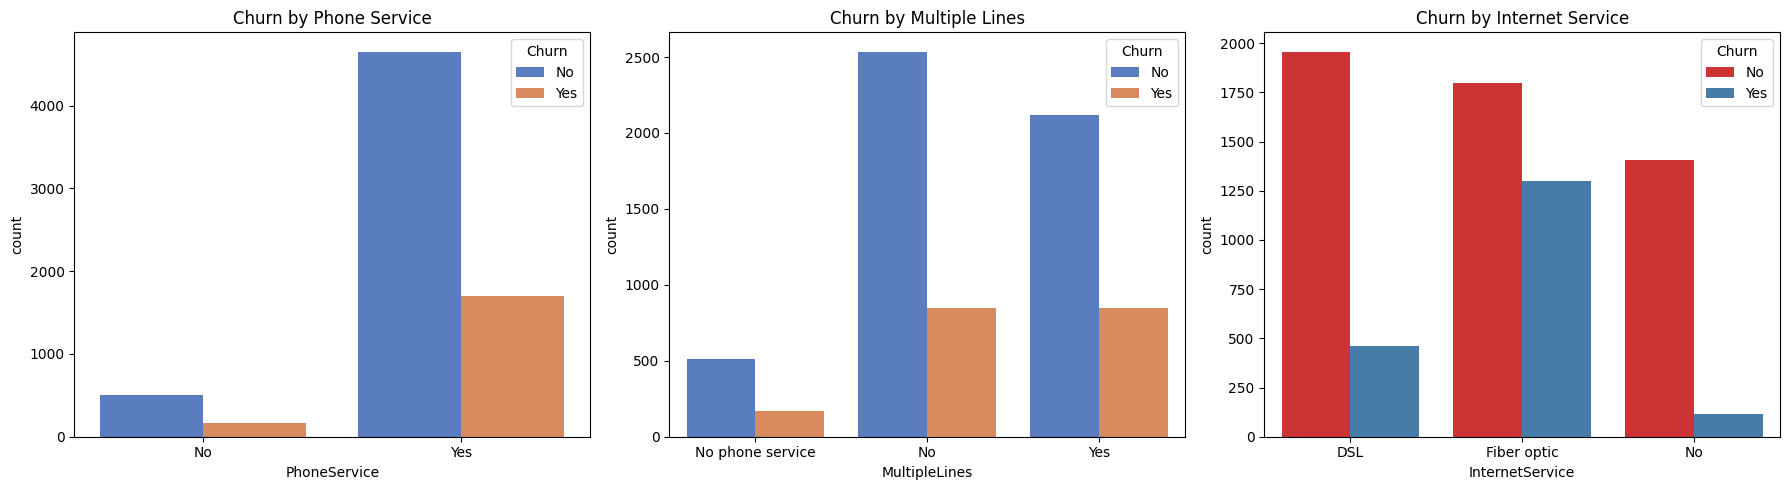

In [32]:
print("--- CORE SERVICES ANALYSIS ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Phone Service
sns.countplot(data=df, x='PhoneService', hue='Churn', palette='muted', ax=axes[0])
axes[0].set_title('Churn by Phone Service')

# Plot 2: Multiple Lines
sns.countplot(data=df, x='MultipleLines', hue='Churn', palette='muted', ax=axes[1])
axes[1].set_title('Churn by Multiple Lines')

# Plot 3: Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1', ax=axes[2])
axes[2].set_title('Churn by Internet Service')

plt.tight_layout()
plt.show()


Looking at that third graph, Fiber optic internet is an absolute disaster for this company.
While the DSL customers are mostly staying, the customers who signed up for Fiber optic are churning at an incredibly high rate.
The company needs to investigate their Fiber optic service immediately.
There might be issues like-

Are they pricing it too high?

Is the network dropping?

Are competitors undercutting them?

Anyways, the InternetService feature is going to be important for us in the prediction.

Since we know Internet Service is a huge factor, let's look at the internet "add-ons". The telecom company offers 6 extra services:
OnlineSecurity

*   OnlineBackup
*   DeviceProtection
*   TechSupport
*   StreamingTV
*   StreamingMovies

Our hypothesis: Customers who buy add-ons (like Security or Tech Support) are more "locked in" to the ecosystem and less likely to leave.

--- INTERNET ADD-ON SERVICES ANALYSIS ---


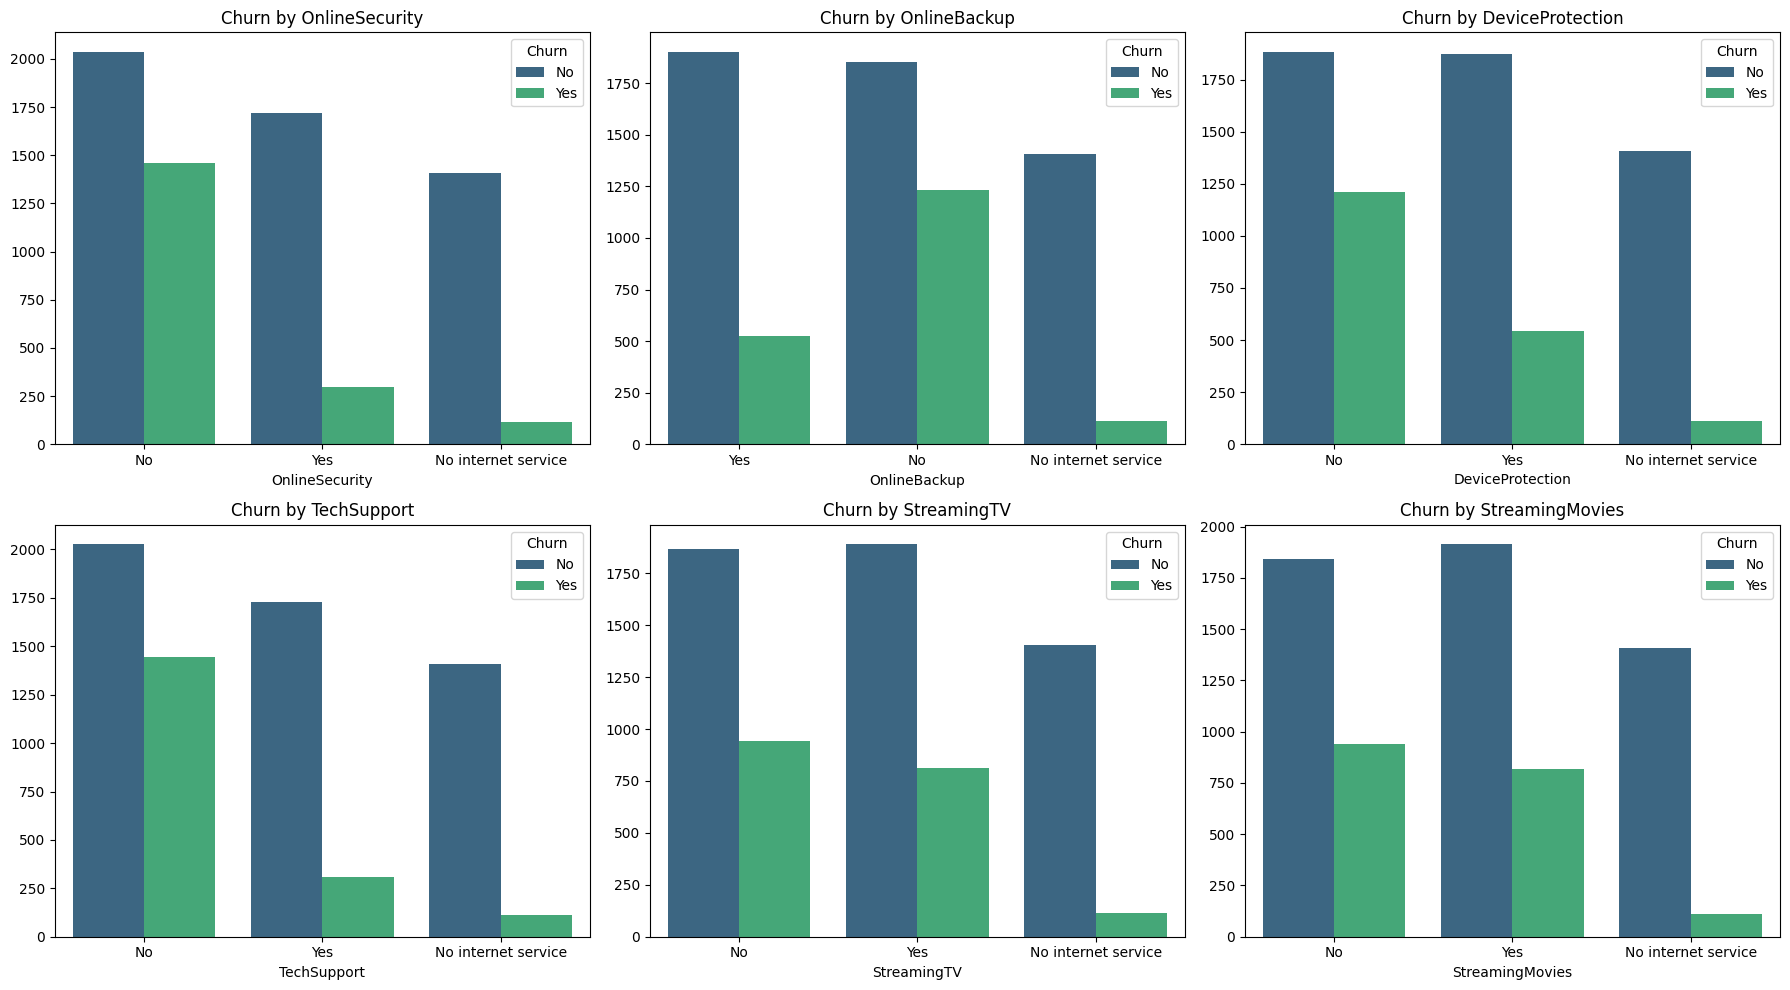

In [33]:
print("--- INTERNET ADD-ON SERVICES ANALYSIS ---")
# List of the 6 add-on columns
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
          'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, addon in enumerate(addons):
    row = i // 3
    col = i % 3
    sns.countplot(data=df, x=addon, hue='Churn', palette='viridis', ax=axes[row, col])
    axes[row, col].set_title(f'Churn by {addon}')
    axes[row, col].set_ylabel('')

plt.tight_layout()
plt.show()

If a customer has "Yes" for either of these, their churn bar (the green one) practically disappears compared to the "No" category.

Business translation: Customers who rely on the company for security and technical help feel "locked in." They don't want to go through the hassle of setting up internet with a new company and losing their dedicated tech support. On the flip side, StreamingTV and StreamingMovies do almost nothing to stop churn (the "Yes" and "No" churn bars are almost the same height).


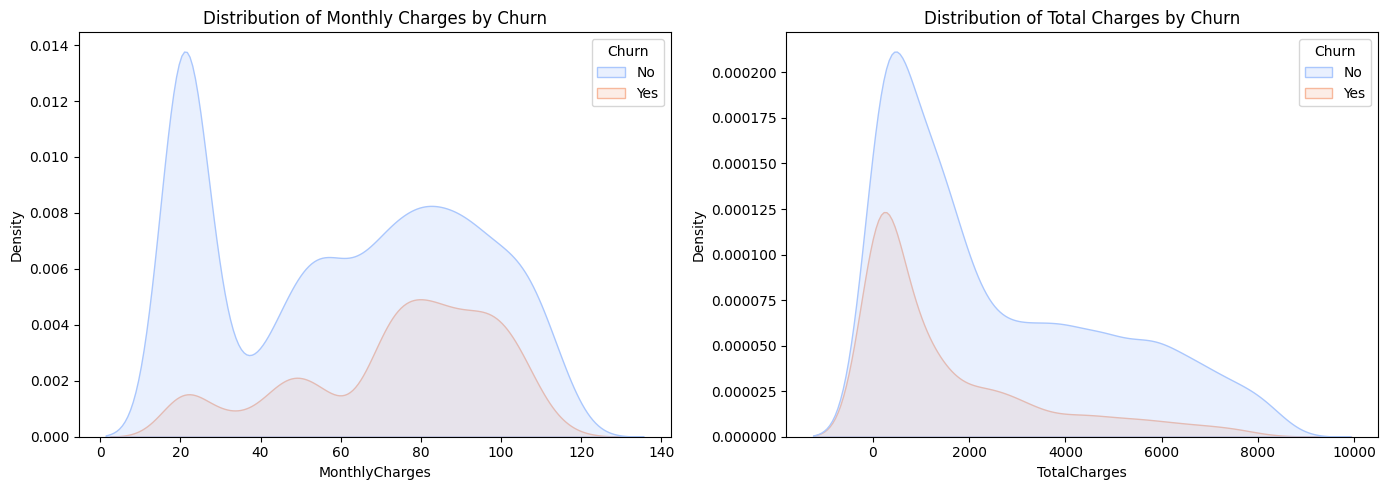

In [34]:
# 1. Force TotalCharges to become numeric (turns blank spaces into NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Now let's plot again!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribution of Monthly Charges by Churn')

sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, palette='coolwarm', ax=axes[1])
axes[1].set_title('Distribution of Total Charges by Churn')

plt.tight_layout()
plt.show()

Let's look at that new Total Charges graph on the right. Notice how the orange "Churn" curve peaks extremely early (near $0 - $1000) and then almost flattens out entirely as it goes to the right?
This perfectly confirms our tenure discovery! People churn early in their lifecycle (which means they haven't accumulated high Total Charges). If a customer stays long enough to rack up $4,000+ in Total Charges, they are practically customers for life.

We are now ready to prepare the data for the actual Machine Learning models.
We must split the data before we scale it to prevent Data Leakage. The model should have zero knowledge of the test set's mean or standard deviation.

Before we split the data into train and test, we need to make sure if we need stratified splitting or we can proceed without it.

In [35]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


So this is an imbalanced dataset, hence we will be using stratified splitting to maintain the ratio we have in the actual training dataset.

In [36]:
print("--- DATA ENCODING ---")

# 1. Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Binary Mapping (Simple 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# 3. Ordinal Encoding for Contract
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# 4. Nominal (One-Hot) Encoding for the rest
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

# drop_first=True prevents the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Old dataset shape: {df.shape}")
print(f"New dataset shape: {df_encoded.shape}")

# Look at the optimized dataset!
display(df_encoded.head())

--- DATA ENCODING ---
Old dataset shape: (7032, 20)
New dataset shape: (7032, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,1,0,1,0,0,0,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (Y)
X = df_encoded.drop('Churn', axis=1)
Y = df_encoded['Churn']

# 2. Train-Test Split (80/20) with Stratification
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 3. Feature Scaling
# We ONLY want to scale the continuous numbers, not our 1/0 encoded columns!
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Fit strictly on train data, then transform both train and test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\n--- Data successfully split and scaled! ---")
display(X_train.head())

X_train shape: (5625, 29)
X_test shape: (1407, 29)

--- Data successfully split and scaled! ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,1,0,1,1,1.321816,1,2,0,0.981556,1.659900,...,1,0,1,0,0,0,0,1,0,0
7003,1,0,0,0,-0.267410,0,0,0,-0.971546,-0.562252,...,1,0,1,0,0,0,0,0,1,0
3355,0,0,1,0,1.444064,1,2,0,0.837066,1.756104,...,1,0,1,0,0,0,0,1,0,0
4494,1,0,0,0,-1.204646,1,0,0,0.641092,-0.908326,...,0,0,0,0,0,0,1,0,1,0
3541,0,0,1,0,0.669826,0,0,0,-0.808787,-0.101561,...,0,0,0,0,1,0,0,0,0,0


We will be keeping logistic regression as our baseline model to work upon.

--- TRAINING LOGISTIC REGRESSION ---
Accuracy Score: 0.8053

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



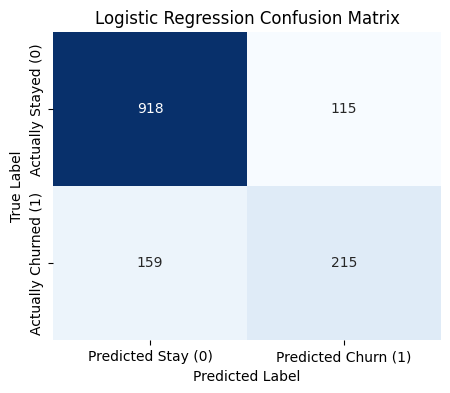

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- TRAINING LOGISTIC REGRESSION ---")

# 1. Initialize and train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, Y_train)

# 2. Make predictions on the unseen test data
Y_pred_log = log_reg.predict(X_test)

# 3. Print Evaluation Metrics
print(f"Accuracy Score: {accuracy_score(Y_test, Y_pred_log):.4f}\n")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_log))

# 4. Plot the Confusion Matrix beautifully
plt.figure(figsize=(5, 4))
cm = confusion_matrix(Y_test, Y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'],
            yticklabels=['Actually Stayed (0)', 'Actually Churned (1)'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

If a model simply guessed "No" (0) for every single customer, it would still get around 73% accuracy just because the data is imbalanced. But that model would be completely useless to the telecom company.

### The Business Perspective:
For a telecom company, a False Negative (predicting a customer will stay, but they actually churn) is disastrous and the company may lose revenue.
A False Positive (predicting they will churn, but they were going to stay anyway) is fine—maybe you accidentally send them a 10% discount promo code. No big deal.

Because of this, we don't care about Accuracy. We care about Recall for Class 1. Right now, your Logistic Regression has a Class 1 Recall of 0.57. That means it completely missed 43% of the actual churners (159 people slipped right through the cracks, as seen in the confusion matrix).

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

print("=== BASELINE ML MODELS WITH BALANCED WEIGHTS ===\n")

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    "SVM (RBF Kernel)": SVC(class_weight='balanced', random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    print(f"--- {name} ---")
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    print(classification_report(Y_test, Y_pred))

    cm = confusion_matrix(Y_test, Y_pred)
    # cm[1,1] is True Positives (Caught Churners), cm[1,0] is False Negatives (Missed Churners)
    total_churners = cm[1,0] + cm[1,1]
    print(f"Result: Caught {cm[1,1]} out of {total_churners} actual churners!\n")
    print("-" * 50 + "\n")

=== BASELINE ML MODELS WITH BALANCED WEIGHTS ===

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Result: Caught 298 out of 374 actual churners!

--------------------------------------------------

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.75      1407

Result: Caught 303 out of 374 actual churners!

--------------------------------------------------

--- SVM (RBF Kernel) ---
              precisi

In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("=== APPLYING LINEAR DISCRIMINANT ANALYSIS (LDA) ===\n")

# Initialize and apply LDA
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train, Y_train)
X_test_lda = lda.transform(X_test)

print(f"Original Feature count: {X_train.shape[1]}")
print(f"LDA Feature count: {X_train_lda.shape[1]} (Massive dimensionality reduction!)\n")

print("=== MODELS TRAINED ON 1D LDA DATA ===\n")

# We will re-use the same balanced models from your previous cell
for name, model in models.items():
    print(f"--- {name} (with LDA) ---")
    model.fit(X_train_lda, Y_train)
    Y_pred_lda = model.predict(X_test_lda)

    print(classification_report(Y_test, Y_pred_lda))

    cm = confusion_matrix(Y_test, Y_pred_lda)
    total_churners = cm[1,0] + cm[1,1]
    print(f"Result: Caught {cm[1,1]} out of {total_churners} actual churners!\n")
    print("-" * 50 + "\n")

=== APPLYING LINEAR DISCRIMINANT ANALYSIS (LDA) ===

Original Feature count: 29
LDA Feature count: 1 (Massive dimensionality reduction!)

=== MODELS TRAINED ON 1D LDA DATA ===

--- Logistic Regression (with LDA) ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.52      0.76      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407

Result: Caught 283 out of 374 actual churners!

--------------------------------------------------

--- Decision Tree (with LDA) ---
              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1033
           1       0.48      0.77      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.73      140

In [41]:
from sklearn.model_selection import GridSearchCV

print("=== HYPERPARAMETER TUNING (OPTIMIZING FOR RECALL) ===\n")

# 1. Logistic Regression Tuning
log_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
print("Tuning Logistic Regression...")
log_grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
                        log_param_grid, scoring='recall', cv=5, n_jobs=-1)
log_grid.fit(X_train, Y_train)

# 2. Decision Tree Tuning
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}
print("Tuning Decision Tree...")
dt_grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42),
                       dt_param_grid, scoring='recall', cv=5, n_jobs=-1)
dt_grid.fit(X_train, Y_train)

# 3. SVM Tuning (Keeping grid slightly smaller as SVM takes longer to train)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}
print("Tuning SVM...\n")
svm_grid = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                        svm_param_grid, scoring='recall', cv=5, n_jobs=-1)
svm_grid.fit(X_train, Y_train)

# --- RESULTS ---
print("=== BEST CROSS-VALIDATION RECALL SCORES ===")
print(f"Best Logistic Regression CV Recall: {log_grid.best_score_:.4f} (Params: {log_grid.best_params_})")
print(f"Best Decision Tree CV Recall:       {dt_grid.best_score_:.4f} (Params: {dt_grid.best_params_})")
print(f"Best SVM CV Recall:                 {svm_grid.best_score_:.4f} (Params: {svm_grid.best_params_})\n")

# Let's see how the Absolute Best Decision Tree performs on the unseen Test Set!
best_dt = dt_grid.best_estimator_
Y_pred_best_dt = best_dt.predict(X_test)

print("=== BEST DECISION TREE TEST SET EVALUATION ===")
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test, Y_pred_best_dt))
cm = confusion_matrix(Y_test, Y_pred_best_dt)
total_churners = cm[1,0] + cm[1,1]
print(f"Result: Caught {cm[1,1]} out of {total_churners} actual churners!")

=== HYPERPARAMETER TUNING (OPTIMIZING FOR RECALL) ===

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning SVM...

=== BEST CROSS-VALIDATION RECALL SCORES ===
Best Logistic Regression CV Recall: 0.8107 (Params: {'C': 0.001, 'solver': 'liblinear'})
Best Decision Tree CV Recall:       0.8054 (Params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 50})
Best SVM CV Recall:                 0.8294 (Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'})

=== BEST DECISION TREE TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Result: Caught 295 out of 374 actual churners!


In [42]:
print("=== BEST SVM TEST SET EVALUATION ===")

# Grab the winning SVM model from the grid search
best_svm = svm_grid.best_estimator_

# Predict on unseen test data
Y_pred_best_svm = best_svm.predict(X_test)

# Evaluate
print(classification_report(Y_test, Y_pred_best_svm))
cm = confusion_matrix(Y_test, Y_pred_best_svm)
total_churners = cm[1,0] + cm[1,1]
print(f"Result: Caught {cm[1,1]} out of {total_churners} actual churners!")

=== BEST SVM TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.60       374

    accuracy                           0.71      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407

Result: Caught 307 out of 374 actual churners!


### Statistical Testing: Independent T-Test
**Objective:** Determine if there is a statistically significant difference in the average tenure of customers who churn versus those who stay.
* **Null Hypothesis ($H_0$):** The average tenure of churners and stayers is the same.
* **Alternate Hypothesis ($H_a$):** The average tenure of churners and stayers is significantly different.
* **Significance Level ($\alpha$):** 0.05

In [43]:
from scipy import stats

print("--- T-TEST: TENURE VS CHURN ---")

# Separate the tenure data into two groups based on Churn
# (Handling both 'Yes'/1 and 'No'/0 depending on your current dataframe state)
churn_yes = df[df['Churn'] == 1]['tenure'] if 1 in df['Churn'].values else df[df['Churn'] == 'Yes']['tenure']
churn_no = df[df['Churn'] == 0]['tenure'] if 0 in df['Churn'].values else df[df['Churn'] == 'No']['tenure']

# Calculate means for context
print(f"Average Tenure (Churned): {churn_yes.mean():.2f} months")
print(f"Average Tenure (Stayed):  {churn_no.mean():.2f} months\n")

# Perform the Independent T-Test
t_stat, p_value = stats.ttest_ind(churn_yes, churn_no, equal_var=False) # Welch's t-test (safer if variances differ)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis. There is a statistically significant difference in tenure between churners and stayers.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis. Tenure does not significantly differ between the two groups.")

--- T-TEST: TENURE VS CHURN ---
Average Tenure (Churned): 17.98 months
Average Tenure (Stayed):  37.65 months

T-Statistic: -34.9719
P-Value:     2.3471e-234

Conclusion: Reject the Null Hypothesis. There is a statistically significant difference in tenure between churners and stayers.


### Statistical Testing: Independent T-Test for Monthly Charges
**Objective:** Determine if customers who churn pay a significantly different monthly rate than those who stay.
* **Null Hypothesis ($H_0$):** Average monthly charges are equal for churners and stayers.
* **Alternate Hypothesis ($H_a$):** Average monthly charges are significantly different.

In [44]:
print("--- T-TEST: MONTHLY CHARGES VS CHURN ---")

# Separate the MonthlyCharges data into two groups based on Churn
charges_churn = df[df['Churn'] == 1]['MonthlyCharges'] if 1 in df['Churn'].values else df[df['Churn'] == 'Yes']['MonthlyCharges']
charges_stay = df[df['Churn'] == 0]['MonthlyCharges'] if 0 in df['Churn'].values else df[df['Churn'] == 'No']['MonthlyCharges']

print(f"Average Monthly Charge (Churned): ${charges_churn.mean():.2f}")
print(f"Average Monthly Charge (Stayed):  ${charges_stay.mean():.2f}\n")

# Perform the Independent T-Test
t_stat_mc, p_value_mc = stats.ttest_ind(charges_churn, charges_stay, equal_var=False)

print(f"T-Statistic: {t_stat_mc:.4f}")
print(f"P-Value:     {p_value_mc:.4e}")

if p_value_mc < 0.05:
    print("\nConclusion: Reject the Null Hypothesis. Churners pay a significantly different monthly rate.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis. No significant difference in monthly rates.")

--- T-TEST: MONTHLY CHARGES VS CHURN ---
Average Monthly Charge (Churned): $74.44
Average Monthly Charge (Stayed):  $61.31

T-Statistic: 18.3409
P-Value:     2.6574e-72

Conclusion: Reject the Null Hypothesis. Churners pay a significantly different monthly rate.


### Statistical Testing: Chi-Square Test of Independence ($\chi^2$)
**Objective:** Determine if there is a statistically significant relationship between our categorical features and Churn.
* **Null Hypothesis ($H_0$):** The feature and Churn are completely independent (The feature is useless).
* **Alternate Hypothesis ($H_a$):** The feature and Churn are dependent (The feature is a good predictor).
* **Significance Level ($\alpha$):** 0.05

In [45]:
from scipy.stats import chi2_contingency

print("--- CHI-SQUARE TEST RESULTS ---\n")

# Identify categorical columns (excluding our target 'Churn' and continuous numericals)
# Note: Even if you mapped Partner/Dependents to 1/0, they act as categories here.
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

print(f"{'Feature':<20} | {'P-Value':<12} | {'Significant Predictor?'}")
print("-" * 60)

for col in cat_cols:
    # Create a contingency table (cross-tabulation)
    contingency_table = pd.crosstab(df[col], df['Churn'])

    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Determine significance
    is_significant = "✅ YES" if p < 0.05 else "❌ NO (Drop it?)"

    # Print formatted results
    print(f"{col:<20} | {p:<12.4e} | {is_significant}")

--- CHI-SQUARE TEST RESULTS ---

Feature              | P-Value      | Significant Predictor?
------------------------------------------------------------
gender               | 4.9049e-01   | ❌ NO (Drop it?)
SeniorCitizen        | 2.4793e-36   | ✅ YES
Partner              | 3.9738e-36   | ✅ YES
Dependents           | 2.0197e-42   | ✅ YES
PhoneService         | 3.4992e-01   | ❌ NO (Drop it?)
MultipleLines        | 3.5679e-03   | ✅ YES
InternetService      | 5.8312e-159  | ✅ YES
OnlineSecurity       | 1.4007e-184  | ✅ YES
OnlineBackup         | 7.7761e-131  | ✅ YES
DeviceProtection     | 1.9594e-121  | ✅ YES
TechSupport          | 7.4078e-180  | ✅ YES
StreamingTV          | 1.3246e-81   | ✅ YES
StreamingMovies      | 5.3536e-82   | ✅ YES
Contract             | 7.3262e-257  | ✅ YES
PaperlessBilling     | 8.2362e-58   | ✅ YES
PaymentMethod        | 1.4263e-139  | ✅ YES


### Statistical Testing: Multicollinearity (Correlation Matrix)
**Objective:** Check if our continuous numerical features are highly correlated with each other.

If two features have a correlation coefficient ($r$) > 0.80, one should typically be dropped to prevent multicollinearity in linear models.

--- NUMERICAL CORRELATION HEATMAP ---


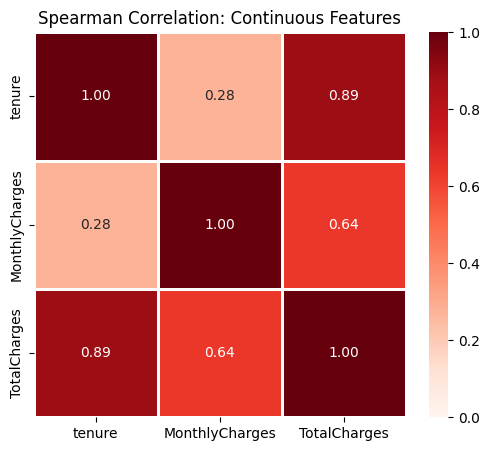

In [46]:
print("--- NUMERICAL CORRELATION HEATMAP ---")

# Select only the continuous numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Calculate the correlation matrix
# Using 'spearman' because we know from our KDE plots that TotalCharges is highly skewed, not a perfect bell curve!
corr_matrix = df[num_cols].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=1, vmin=0, vmax=1)
plt.title("Spearman Correlation: Continuous Features")
plt.show()

### Advanced Feature Engineering & Data Purging
Based on our rigorous statistical testing, we will:
1. **Drop Useless Features:** `gender` and `PhoneService` (Failed Chi-Square test, $p > 0.05$).
2. **Drop Multicollinear Features:** `TotalCharges` (Spearman correlation of 0.89 with `tenure`).
3. **Engineer `Is_Family`:** Combine `Partner` and `Dependents` into a single binary flag.
4. **Engineer `Total_Addons`:** Sum the number of extra internet services (0 to 6) to measure ecosystem lock-in.
5. **Engineer `Is_Auto_Pay`:** Flag automatic payment methods to capture the "friction" of manual billing.

In [47]:
print("--- ADVANCED FEATURE ENGINEERING ---")

# 1. Purge the mathematically useless columns
cols_to_drop = ['gender', 'PhoneService', 'TotalCharges']
df = df.drop(columns=cols_to_drop)
print(f"Dropped: {cols_to_drop}")

# 2. Engineer: Is_Family
# If they have a Partner OR Dependents, they are a family unit (1). Otherwise, solo (0).
df['Is_Family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)

# 3. Engineer: Total_Addons
# Count how many 'Yes' values they have across the 6 internet add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Addons'] = (df[addon_cols] == 'Yes').sum(axis=1)

# 4. Engineer: Is_Auto_Pay
# 1 if automatic, 0 if manual
df['Is_Auto_Pay'] = df['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x else 0)

print(f"\nNew Engineered Dataset Shape: {df.shape}")
display(df[['Partner', 'Dependents', 'Is_Family', 'Total_Addons', 'PaymentMethod', 'Is_Auto_Pay']].head())

--- ADVANCED FEATURE ENGINEERING ---
Dropped: ['gender', 'PhoneService', 'TotalCharges']

New Engineered Dataset Shape: (7032, 20)


,Partner,Dependents,Is_Family,Total_Addons,PaymentMethod,Is_Auto_Pay
0,1,0,0,1,Electronic check,0
1,0,0,0,2,Mailed check,0
2,0,0,0,2,Mailed check,0
3,0,0,0,3,Bank transfer (automatic),1
4,0,0,0,0,Electronic check,0


In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- REBUILDING MASTER DATA PIPELINE ---")

# 1. Load fresh data to reset memory state
df = pd.read_csv('/content/customer_churn.csv') # Ensure path matches your setup

# 2. Initial Data Cleaning
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Drop the 11 "Day 0" customers

# 3. Advanced Feature Engineering
df['Is_Family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)

addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Addons'] = (df[addon_cols] == 'Yes').sum(axis=1)

df['Is_Auto_Pay'] = df['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x else 0)

# 4. Purge Useless & Multicollinear Features
cols_to_drop = ['gender', 'PhoneService', 'TotalCharges', 'Partner', 'Dependents']
df = df.drop(columns=cols_to_drop)

# 5. Ordinal & Binary Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# 6. One-Hot Encoding for remaining nominal features
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

# 7. Train-Test Split (Stratified)
X = df_encoded.drop('Churn', axis=1)
Y = df_encoded['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 8. Post-Split Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'Total_Addons'] # Total_Addons is treated as a continuous scale 0-6

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✅ Pipeline Success! Data is Cleaned, Engineered, Encoded, Split, and Scaled.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

--- REBUILDING MASTER DATA PIPELINE ---
✅ Pipeline Success! Data is Cleaned, Engineered, Encoded, Split, and Scaled.
X_train shape: (5625, 27)
X_test shape: (1407, 27)


=== RE-TUNING SVM ON NEW ENGINEERED DATASET ===
Tuning SVM... (Give it ~30-60 seconds to run the math!)

Best Parameters Found: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}

=== FINAL SVM TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.91      0.66      0.77      1033
           1       0.47      0.82      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407

Result: Caught 305 out of 374 actual churners!


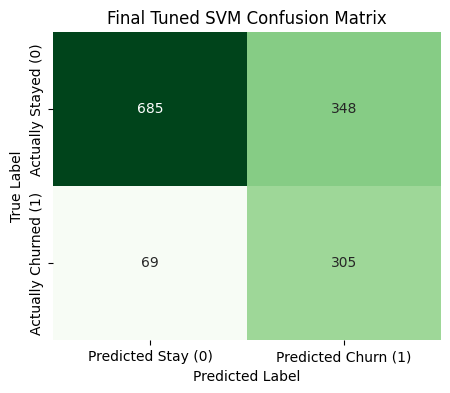

In [50]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== RE-TUNING SVM ON NEW ENGINEERED DATASET ===")

# Same parameter grid as before
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

print("Tuning SVM... (Give it ~30-60 seconds to run the math!)")

# 1. Re-train the GridSearch on the NEW X_train
svm_grid = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                        svm_param_grid, scoring='recall', cv=5, n_jobs=-1)
svm_grid.fit(X_train, Y_train)

# 2. Grab the new best model
best_svm = svm_grid.best_estimator_
print(f"\nBest Parameters Found: {svm_grid.best_params_}")

# 3. Predict on the NEW X_test
Y_pred_best_svm = best_svm.predict(X_test)

# 4. Evaluate!
print("\n=== FINAL SVM TEST SET EVALUATION ===")
print(classification_report(Y_test, Y_pred_best_svm))

cm = confusion_matrix(Y_test, Y_pred_best_svm)
total_churners = cm[1,0] + cm[1,1]
print(f"Result: Caught {cm[1,1]} out of {total_churners} actual churners!")

# Plot the final confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'],
            yticklabels=['Actually Stayed (0)', 'Actually Churned (1)'])
plt.title('Final Tuned SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()